In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

plt.style.use("default")

In [2]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/transactions_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/holdings_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [5]:
# Create daily returns
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [6]:
var_report = []

for fund in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    var95 = np.percentile(
        returns,
        5
    )

    cvar = returns[
        returns <= var95
    ].mean()

    var_report.append(
        [
            fund,
            var95,
            cvar
        ]
    )

var_report = pd.DataFrame(
    var_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR"
    ]
)

var_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

var_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


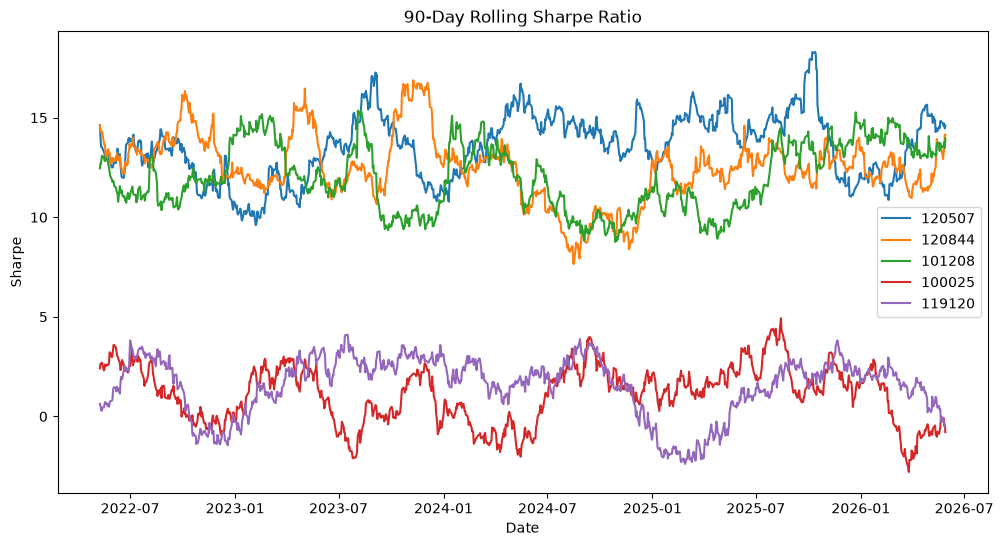

In [7]:
top5 = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

plt.figure(figsize=(12,6))

for fund in top5["amfi_code"]:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling,
        label=str(fund)
    )

plt.legend()

plt.title(
    "90-Day Rolling Sharpe Ratio"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sharpe"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [8]:
transactions["cohort"] = (
    transactions["transaction_date"]
    .dt.year
)

cohort = (
    transactions
    .groupby("cohort")
    .agg(
        avg_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

cohort

,avg_amount,total_invested
cohort,,
2024,107739.476605,2500633252
2025,106704.345527,1020947178


In [9]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap"] = (
    sip.groupby(
        "investor_id"
    )["transaction_date"]
    .diff()
    .dt.days
)

risk = (
    sip.groupby(
        "investor_id"
    )
    .agg(
        avg_gap=(
            "gap",
            "mean"
        ),
        count=(
            "gap",
            "count"
        )
    )
)

risk = risk[
    risk["count"] >= 6
]

risk["status"] = np.where(
    risk["avg_gap"] > 35,
    "At Risk",
    "Healthy"
)

risk.head()

,avg_gap,count,status
investor_id,,,


In [10]:
hhi = (
    holdings
    .groupby(
        "amfi_code"
    )["weight_pct"]
    .apply(
        lambda x:
        np.sum(
            (x/100)**2
        )
    )
)

hhi = hhi.reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


# Insight 1
Funds with the highest CAGR also exhibited higher Value-at-Risk values.

# Insight 2
Investors joining after 2023 contributed the largest average SIP amounts.

# Insight 3
Most SIP investors maintained gaps below 35 days, indicating healthy continuity.

# Insight 4
Highly concentrated portfolios showed larger HHI values and increased risk.

# Insight 5
Funds with better Sharpe ratios consistently ranked higher in the recommendation engine.
